In [1]:
import os
import numpy as np
# import abtem
# from ase.build import bulk, surface
# from scipy.special import erf
from scipy.ndimage import gaussian_filter
# import skimage
# from tifffile import imread
import kemstem
import tifffile
from scipy.spatial import cKDTree
from matplotlib import pyplot as plt, colors, colormaps, cm
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
# from sklearn.cluster import KMeans
# from scipy.optimize import linear_sum_assigAent
# from scipy.spatial.distance import cdist
# from scipy.interpolate import griddata
# import imageio.v3 as iio
# %matplotlib inline

plt.rcParams['font.family'] = 'monospace'

In [5]:
basedir = "/home/swim/Si_project/260707_BCAT_tif_file"
os.listdir(basedir)

['f_410_1_obj_phase_roi_Niter100.tiff',
 'f_410_2_obj_phase_roi_Niter100.tiff',
 'f_410_3_obj_phase_roi_Niter100.tiff',
 'f_410_4_obj_phase_roi_Niter100.tiff',
 'f_420_1_obj_phase_roi_Niter120.tiff',
 'f_420_2_obj_phase_roi_Niter120.tiff',
 'f_420_3_obj_phase_roi_Niter120.tiff',
 'f_420_4_obj_phase_roi_Niter120.tiff',
 'f_430_1_obj_phase_roi_Niter80.tiff',
 'f_430_2_obj_phase_roi_Niter80.tiff',
 'f_430_3_obj_phase_roi_Niter80.tiff',
 'f_430_4_obj_phase_roi_Niter80.tiff',
 'f_450_1_obj_phase_roi_Niter90.tiff',
 'f_450_2_obj_phase_roi_Niter90.tiff',
 'f_450_3_obj_phase_roi_Niter90.tiff',
 'f_450_4_obj_phase_roi_Niter90.tiff',
 'f_471_1_obj_phase_roi_Niter50.tiff',
 'f_471_2_obj_phase_roi_Niter50.tiff',
 'f_471_3_obj_phase_roi_Niter50.tiff',
 'f_471_4_obj_phase_roi_Niter50.tiff',
 'f_471_5_obj_phase_roi_Niter230.tiff',
 'f_471_6_obj_phase_roi_Niter230.tiff',
 'f_471_7_obj_phase_roi_Niter230.tiff',
 'f_472_1_obj_phase_roi_Niter50.tiff',
 'f_472_2_obj_phase_roi_Niter50.tiff',
 'f_472_3_obj_

Shape : (379, 379)
Dtype : uint8
H × W : 379 × 379
Pixel Size : 0.24 A/px


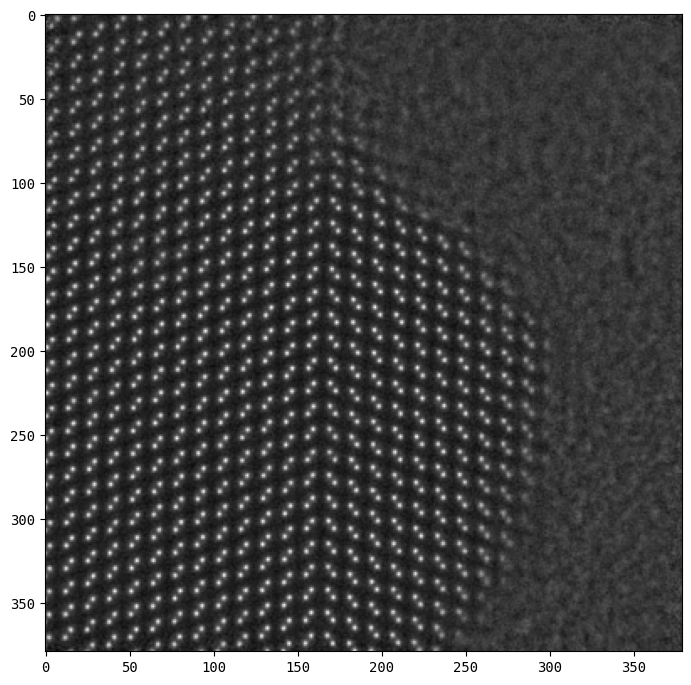

In [6]:
tiff = 'f_410_3_obj_phase_roi_Niter100.tiff'
image_file = os.path.join(basedir, tiff)
layer = 16
image = tifffile.imread(image_file)[layer]

roi_A = 92
A_per_px = roi_A / image.shape[0]  # A/pixel
Si_distance_px = 1.358 / A_per_px


print(f"Shape : {image.shape}")
print(f"Dtype : {image.dtype}")
print(f"H × W : {image.shape[0]} × {image.shape[1]}")
print(f"Pixel Size : {A_per_px:.2f} A/px")

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(image, cmap='gray')
# ax.set_title(f"Raw Image  ({image.shape[0]} × {image.shape[1]} px)")
# ax.axis('on')   # 픽셀 좌표 눈금 표시
plt.tight_layout()
plt.show()

1036 columns found


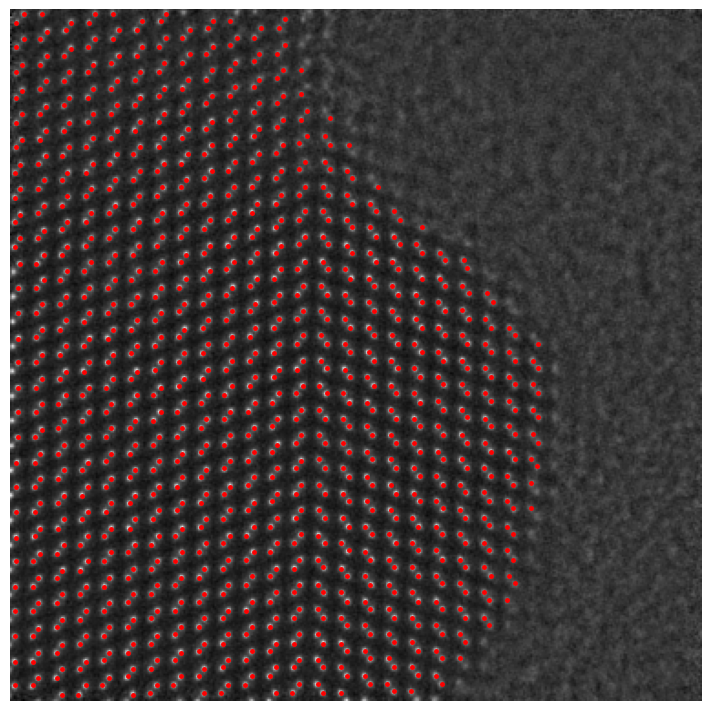

In [7]:
# gaussian_filter는 find_columns 보조용으로만, refine은 image로
blurred_image = gaussian_filter(image, 1)
distance = 2       # 원자 간격 픽셀의 절반 정도로 조정
threshold = 0.5

c0 = kemstem.find_columns(blurred_image, distance=distance, threshold=threshold)

fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(7, 7))
ax.imshow(image, cmap='gray')   # matshow → imshow 통일
ax.axis('off')
ax.plot(c0[:, 1], c0[:, 0], 'r.', markersize=5)
print(f'{c0.shape[0]} columns found')

In [8]:
# # 1. 반드시 widget 모드로 설정 (VS Code/Jupyter Lab 권장)
# %matplotlib widget 
# import matplotlib.pyplot as plt
# import numpy as np

# # 만약 widget 모드가 지원되지 않는 환경이라면 에러가 날 수 있습니다.
# # 그럴 경우 다시 알려주세요.

# class AtomEditor:
#     def __init__(self, img, coords):
#         self.img = img
#         self.coords = list(coords)
#         self.fig, self.ax = plt.subplots(figsize=(7, 7))
#         self.ax.imshow(self.img, cmap='gray')
        
#         # 초기 원자 표시 (데이터가 없을 경우를 대비해 빈 리스트 처리)
#         x_init = [c[1] for c in self.coords] if self.coords else []
#         y_init = [c[0] for c in self.coords] if self.coords else []
#         self.points, = self.ax.plot(x_init, y_init, 'r.', markersize=3)
        
#         self.ax.set_title("Left Click: Add (+) | Right Click: Remove (-)")
        
#         # 클릭 이벤트 연결
#         self.fig.canvas.mpl_connect('button_press_event', self.on_click)

#     def on_click(self, event):
#         # 마우스가 이미지 안에 있지 않으면 무시
#         if event.inaxes != self.ax: return
        
#         if event.button == 1:  # 왼쪽 클릭: 추가
#             self.coords.append([event.ydata, event.xdata])
            
#         elif event.button == 3:  # 오른쪽 클릭: 삭제
#             if len(self.coords) == 0: return
#             # 클릭한 지점에서 가장 가까운 원자 찾기
#             dists = np.sqrt([(c[0]-event.ydata)**2 + (c[1]-event.xdata)**2 for c in self.coords])
#             closest_idx = np.argmin(dists)
#             if dists[closest_idx] < 15:  # 15픽셀 이내일 때만 삭제 (너무 멀면 실수 방지)
#                 self.coords.pop(closest_idx)

#         self.update_plot()

#     def update_plot(self):
#         # 좌표 업데이트 후 즉시 다시 그리기
#         if len(self.coords) > 0:
#             y, x = zip(*self.coords)
#             self.points.set_data(x, y)
#         else:
#             self.points.set_data([], [])
        
#         # 화면 강제 갱신
#         self.fig.canvas.draw_idle()

# # 실행 (기존에 찾은 원자 좌표 c0 전달)
# editor = AtomEditor(blurred_image, c0)

In [9]:
# # 에디터 객체(editor) 내부에 저장된 리스트를 numpy 배열로 변환하여 c0에 덮어쓰기
# c0 = np.array(editor.coords)

# print(f"✅ 수동 수정 후 c0 개수: {len(c0)}개")
# %matplotlib inline
# plt.close()
# # 여기서 개수가 늘어난 것을 확인했다면 성공입니다.

100%|██████████| 1/1 [00:00<00:00, 104.77it/s]


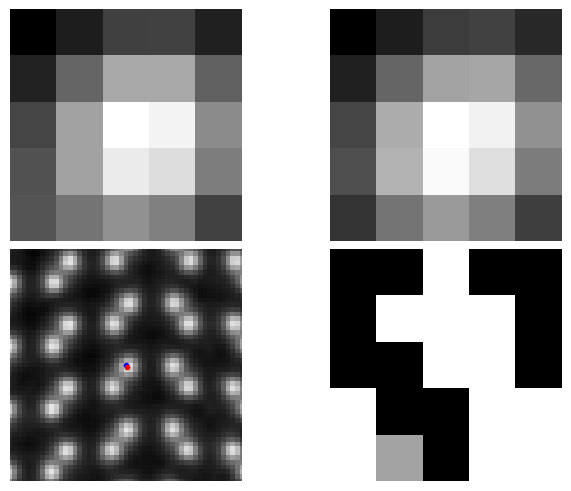

In [10]:
test_it = 100
window_dim = 5
cf,errs,opts,data_fits = kemstem.refine_columns(blurred_image,c0[test_it,:],window_dim)

visualization_window = 5*window_dim
fig,ax = plt.subplots(2,2,constrained_layout=True)
ax[0,0].matshow(data_fits[:,:,0,0],cmap='gray')
ax[0,1].matshow(data_fits[:,:,0,1],cmap='gray')
ax[1,0].matshow(blurred_image,cmap='gray')
ax[1,0].plot(c0[test_it,1],c0[test_it,0],'b.') # original unfit position shown in blue
ax[1,0].plot(cf[0,1],cf[0,0],'r.') # fit position shown in red
ax[1,0].set_xlim([c0[test_it,1]-visualization_window,c0[test_it,1]+visualization_window])
ax[1,0].set_ylim([c0[test_it,0]+visualization_window,c0[test_it,0]-visualization_window])
ax[1,1].matshow(data_fits[:,:,0,0]-data_fits[:,:,0,1],cmap='gray',vmin=-.1,vmax=.1) # fit residual
_ = [tax.axis('off') for tax in ax.ravel()]

In [11]:
cf, errs, opts, data_fits = kemstem.refine_columns(image, c0, window_dim)

100%|██████████| 1036/1036 [00:03<00:00, 302.79it/s]


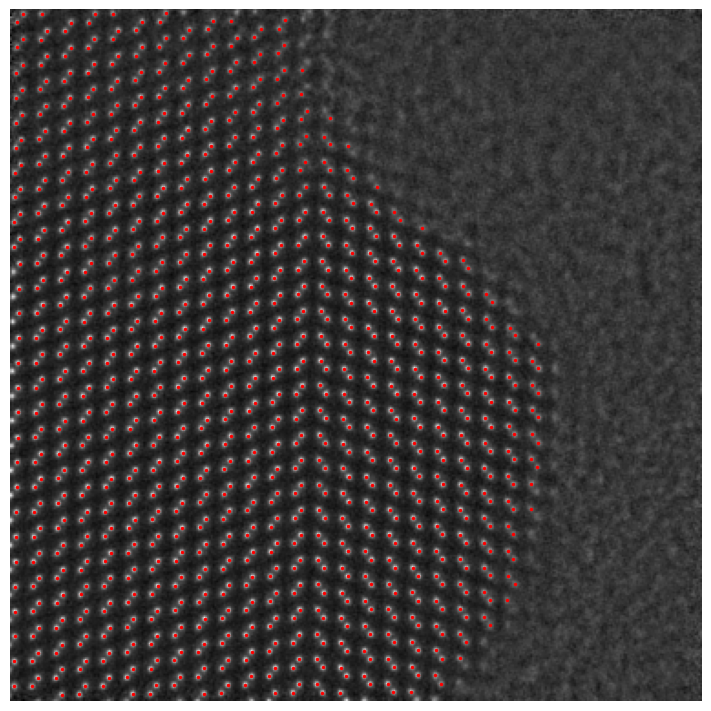

In [12]:
fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(7, 7))
ax.imshow(image, cmap='gray')   # matshow → imshow
ax.plot(cf[:, 1], cf[:, 0], 'r.', markersize=3)
ax.axis('off')
plt.show()

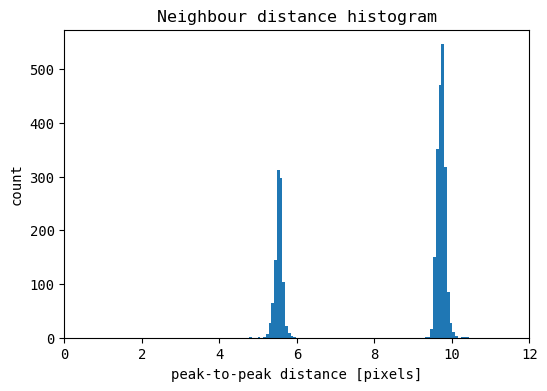

In [13]:
atoms_xy = cf[:,::-1]

tree = cKDTree(atoms_xy)

dists, inds = tree.query(atoms_xy, k=7)

nearest_distances = dists[:, 1:].ravel()

plt.figure(figsize=(6, 4))
plt.hist(nearest_distances[nearest_distances < 12], bins=80)
plt.xlim(0, 12)
plt.xlabel("peak-to-peak distance [pixels]")
plt.ylabel("count")
plt.title("Neighbour distance histogram")
plt.show()

In [14]:
# Cell 7
# Choose a dumbbell-pairing distance window in pixels.
# For a real image, inspect the histogram above and set these manually.

d_min = 4
d_max = 6

# Cell 8
# Make all candidate close pairs within the dumbbell distance window.

pairs = []

for i, p in enumerate(atoms_xy):
    neighbours = tree.query_ball_point(p, r=d_max)

    for j in neighbours:
        if j <= i:
            continue

        q = atoms_xy[j]
        d = np.linalg.norm(q - p)

        if d_min <= d <= d_max:
            pairs.append((i, j, d))

pairs = np.array(pairs, dtype=float)
len(pairs)

499

In [15]:
# Cell 9
# Greedy pairing:
# sort candidate pairs by distance and assign each atom to at most one dumbbell.

pairs_sorted = pairs[np.argsort(pairs[:, 2])]

used = set()
dumbbells = []

for i, j, d in pairs_sorted:
    i = int(i)
    j = int(j)

    if i in used or j in used:
        continue

    dumbbells.append((i, j, d))
    used.add(i)
    used.add(j)

dumbbells = np.array(dumbbells, dtype=float)

len(dumbbells)

499

In [16]:
# Cell 10
# Extract dumbbell geometry:
# center, vector, length, and angle.

dumbbell_centers = []
dumbbell_vectors = []
dumbbell_lengths = []
dumbbell_angles = []

for i, j, d in dumbbells:
    i = int(i)
    j = int(j)

    p = cf[i]
    q = cf[j]

    center = 0.5 * (p + q)
    vector = q - p
    length = np.linalg.norm(vector)
    angle = np.degrees(np.arctan2(vector[1], vector[0]))

    dumbbell_centers.append(center)
    dumbbell_vectors.append(vector)
    dumbbell_lengths.append(length)
    dumbbell_angles.append(angle)

dumbbell_centers = np.array(dumbbell_centers)
dumbbell_vectors = np.array(dumbbell_vectors)
dumbbell_lengths = np.array(dumbbell_lengths)
dumbbell_angles = np.array(dumbbell_angles)

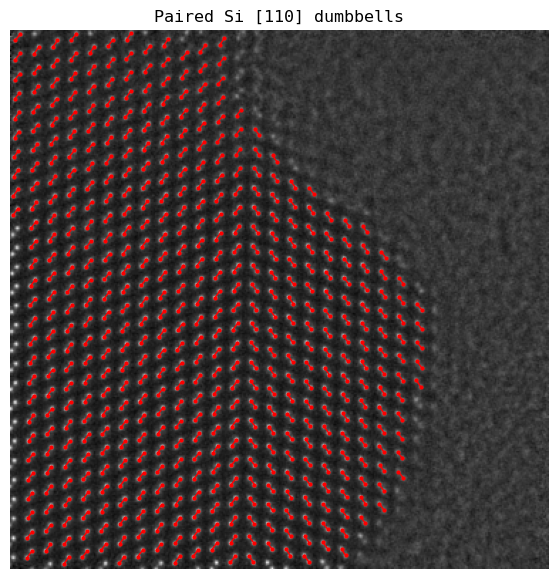

In [17]:
# Cell 11
plt.figure(figsize=(7, 7))
plt.imshow(image, cmap="gray")

# plt.scatter(
#     atoms_xy[:, 0],
#     atoms_xy[:, 1],
#     s=20,
#     facecolors="none",
#     edgecolors="r"
# )

for i, j, d in dumbbells:
    i = int(i)
    j = int(j)

    p = atoms_xy[i]
    q = atoms_xy[j]

    plt.plot(
        [p[0], q[0]],
        [p[1], q[1]],
        'ro-',
        linewidth=1,
        markersize=2
    )

plt.axis("off")
plt.title("Paired Si [110] dumbbells")
plt.show()

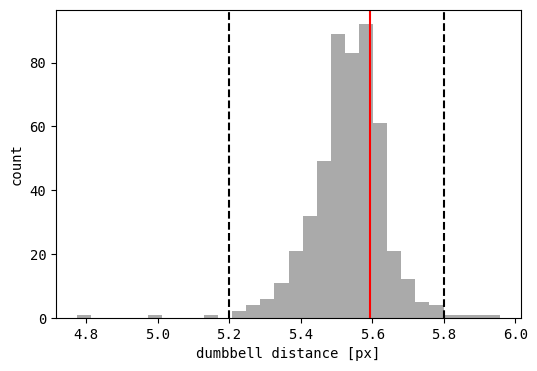

In [18]:
# Cell 11
# Histogram of dumbbell distances.
# Inspect this plot, then choose vmin and vmax manually in the next cell.

dumbbell_distances = dumbbells[:, 2]

plt.figure(figsize=(6, 4), dpi=100)
plt.hist(dumbbell_distances, bins=30, color='#aaa')
# xticks, xticklabels = plt.xticks()
# plt.xticks(xticks, np.round(xticks * A_per_px, 2))
plt.xlabel("dumbbell distance [px]")
plt.ylabel("count")
# plt.title("Histogram of Si [110] dumbbell distances")

vmin = 5.2
vmax = 5.8

plt.axvline(vmin, color='k', linestyle='--', label=f'vmin = {vmin:.2f}')
plt.axvline(vmax, color='k', linestyle='--', label=f'vmax = {vmax:.2f}')
plt.axvline(Si_distance_px, color='red', linestyle='-', label=f'vmax = {vmax:.2f}')

plt.show()

In [19]:
# plt.figure(figsize=(4, 4), dpi=100)
# plt.hist(dumbbell_distances, bins=30, color='#aaa')
# xticks, xticklabels = plt.xticks()
# plt.xticks(xticks, np.round(xticks * A_per_px, 2))
# plt.xlabel("dumbbell distance [Å]")
# plt.ylabel("count")
# plt.axvline(vmin, color=plt.cm.viridis.colors[0], linestyle='--', label=f'vmin = {vmin:.2f}')
# plt.axvline(vmax, color=plt.cm.viridis.colors[-1], linestyle='--', label=f'vmax = {vmax:.2f}')
# plt.axvline(Si_distance_px, color='red', linestyle='-', label=f'vmax = {vmax:.2f}')

# plt.show()

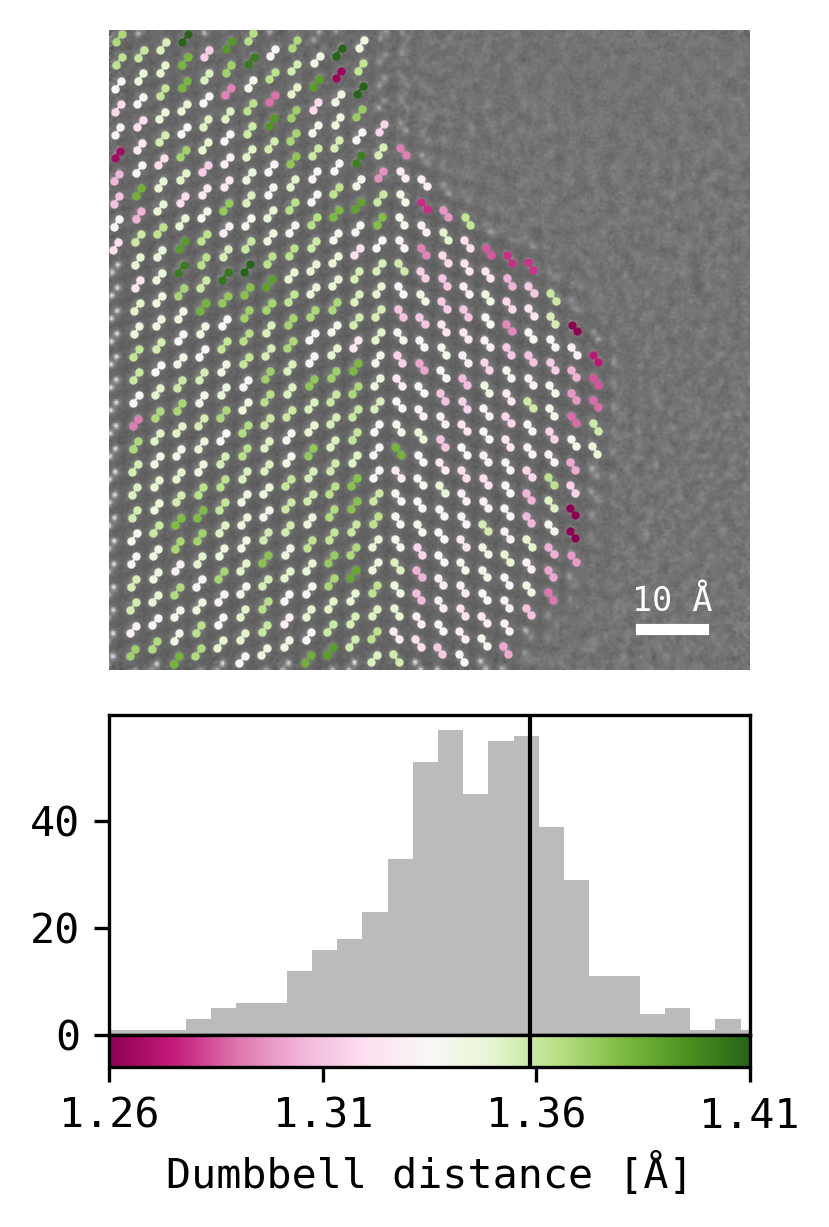

In [27]:
# 1. Create the figure and axes
fig, axs = plt.subplots(2, 1, dpi=300)
ax1, ax2 = axs

norm = colors.Normalize(vmin=vmin, vmax=vmax, clip=True)
cmap = colormaps['PiYG']
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Keep the original 1:1 aspect ratio for the image
ax1.imshow(image, cmap="gray", alpha=.7)
ax1.axis('off')

for i, j, d in dumbbells:
    i, j = int(i), int(j)
    p, q = atoms_xy[i], atoms_xy[j]
    ax1.plot([p[0], q[0]], [p[1], q[1]], 'o-', linewidth=.5, markersize=1, color=cmap(norm(d)))

# Plot the histogram
ax2.hist(dumbbell_distances, bins=50, color='#bbb')
ax2.axvline(Si_distance_px, color='k', linewidth=1)
ax2.set_xlim(vmin, vmax)
# Turn off the histogram's x-axis ticks/labels since the colorbar replaces it
ax2.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

# 2. Force layout geometry matching
plt.tight_layout() # Initial pass to establish image bounds based on 1:1 aspect
fig.canvas.draw()  # Evaluate positions

# Get the physical layout position of the image channel
pos1 = ax1.get_position()
pos2 = ax2.get_position()

# Adjust the histogram height here (e.g., matching 60% of its original height)
new_hist_height = pos2.height * 0.5

# Update ax2 to match ax1's horizontal span exactly, with your custom height
ax2.set_position([pos1.x0, pos2.y0 + (pos2.height - new_hist_height), pos1.width, new_hist_height])

# 3. Add the colorbar exactly flush beneath the modified histogram
# [left, bottom, width, height] relative to ax2
cax = ax2.inset_axes([0, -0.1, 1, 0.1], transform=ax2.transAxes)
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_ticks(cbar.get_ticks()) # type: ignore
cbar.set_ticklabels(np.round(A_per_px * cbar.get_ticks(), 2))
cbar.ax.axvline(Si_distance_px, color='k', linewidth=1)
cbar.ax.set_xlabel('Dumbbell distance [Å]')
cbar.ax.set_xlim(vmin, vmax)

sbar_length_A = 10

sbar_length_px = sbar_length_A // A_per_px

scalebar = AnchoredSizeBar(
    ax1.transData,
    sbar_length_px,                # Size of the scale bar in data units (pixels)
    f'{sbar_length_A} Å',          # Text label
    loc='lower right',            # Position (e.g., 'lower right', 'lower left')
    pad=1,                      # Padding inside the box
    color='white',                # Color of the bar and text
    frameon=False,                # Remove background box boundary
    size_vertical=sbar_length_px * 0.1, # Thickness of the scale bar line
    label_top=True,
    fontproperties={'weight': 'normal', 'size': 8} # Optional: fine-tune text style/size
)
ax1.add_artist(scalebar)

# scale_bar_A = 10
# scale_bar_px = scale_bar_A // A_per_px

# scale_bar_start_px = 30
# scale_bar_x = [scale_bar_start_px, scale_bar_start_px+scale_bar_px]
# scale_bar_y = [350] * 2
# sbar = ax1.plot(scale_bar_x, scale_bar_y, color='black', linewidth=4)
# sbar.text(scale_bar_start_px, 340, "10 Å", size=10)

plt.show()